In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print("libraries imported")

libraries imported


In [64]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetes.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jamaltariqcheema/pima-indians-diabetes-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
print("dataset_loaded")
print("First 5 records:", df.head())
df.shape

C:\Users\bushr\AppData\Local\Temp\ipykernel_21564\296855789.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


dataset_loaded
First 5 records:    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


(768, 9)

In [65]:
print("data preprocessing")
df.info()
df.describe()
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)
df.isnull().sum()

data preprocessing
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [66]:
for column in columns_with_zero:
    df[column] = df[column].fillna(df[column].median())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [67]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target:
Outcome


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [69]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("data has been scaled")

data has been scaled


In [70]:
svm_model = SVC(kernel="linear")
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print(y_pred_svm)

[0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 1 0 1 1
 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 1 0]


In [71]:

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
print("SVM Results")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

SVM Results
Accuracy : 0.7922077922077922
Precision: 0.7346938775510204
Recall   : 0.6545454545454545
F1 Score : 0.6923076923076923


[[86 13]
 [19 36]]


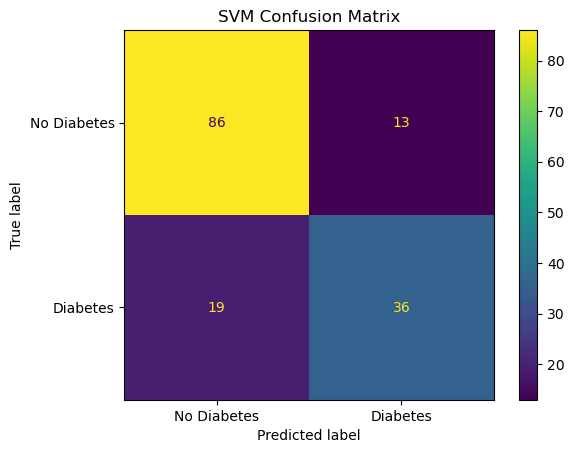

In [72]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Diabetes", "Diabetes"]
)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [73]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print(y_pred_dt)


[0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0
 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 1 0
 0 1 1 0 0 0]


In [74]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
Accuracy : 0.8376623376623377
Precision: 0.75
Recall   : 0.8181818181818182
F1 Score : 0.782608695652174


[[84 15]
 [10 45]]


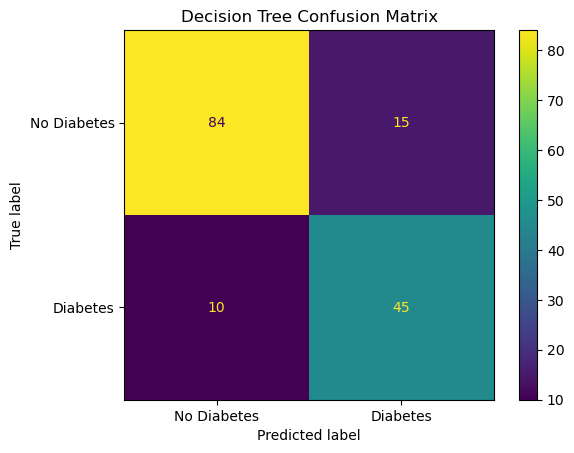

In [75]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Diabetes", "Diabetes"]
)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [76]:
print("both models comparison")
results = pd.DataFrame({
    "Model": ["SVM", "Decision Tree"],
    "Accuracy": [svm_accuracy, dt_accuracy],
    "Precision": [svm_precision, dt_precision],
    "Recall": [svm_recall, dt_recall],
    "F1 Score": [svm_f1, dt_f1]
})
results

both models comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.792208,0.734694,0.654545,0.692308
1,Decision Tree,0.837662,0.750000,0.818182,0.782609


comparison plot


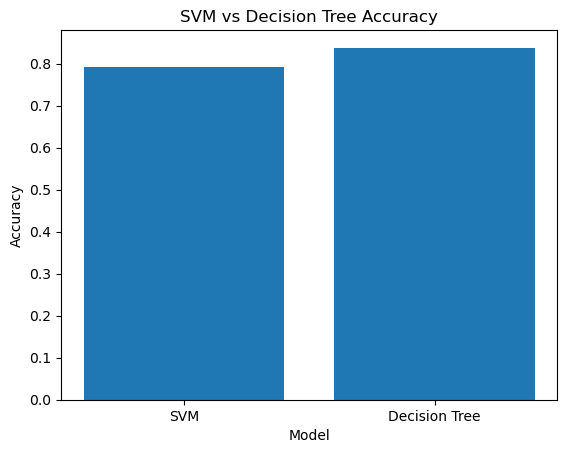

In [77]:
print("comparison plot")
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("SVM vs Decision Tree Accuracy")
plt.show()

In [84]:
svm_train_accuracy = svm_model.score(X_train_scaled, y_train)
dt_train_accuracy = dt_model.score(X_train, y_train)

print("SVM Training Accuracy:", svm_train_accuracy)
print("SVM Testing Accuracy :", svm_accuracy)
print()
print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Testing Accuracy :", dt_accuracy)
print("the above results indicate that the descision tree is overfitting.\nit performs extremely well in training but worst in testing.")

SVM Training Accuracy: 0.7736156351791531
SVM Testing Accuracy : 0.7922077922077922

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy : 0.8376623376623377
the above results indicate that the descision tree is overfitting.
it performs extremely well in training but worst in testing


In [86]:
print("to reduce the overfitting of descision tree,\n we will limit it\n using max_Depth")

to reduce the overfitting of descision tree,
 we will limit it
 using max_Depth


In [87]:
dt_model2 = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
dt_model2.fit(X_train, y_train)
y_pred_dt2 = dt_model2.predict(X_test)

In [89]:
print("results of limited decison tree")
dt2_accuracy = accuracy_score(y_test, y_pred_dt2)
dt2_precision = precision_score(y_test, y_pred_dt2)
dt2_recall = recall_score(y_test, y_pred_dt2)
dt2_f1 = f1_score(y_test, y_pred_dt2)

print("Decision Tree with max_depth=4")
print("Accuracy :", dt2_accuracy)
print("Precision:", dt2_precision)
print("Recall   :", dt2_recall)
print("F1 Score :", dt2_f1)
dt2_train_accuracy = dt_model2.score(X_train, y_train)
print("Training Accuracy:", dt2_train_accuracy)
print("Testing Accuracy :", dt2_accuracy)

results of limited decison tree
Decision Tree with max_depth=4
Accuracy : 0.8506493506493507
Precision: 0.7580645161290323
Recall   : 0.8545454545454545
F1 Score : 0.8034188034188035
Training Accuracy: 0.9087947882736156
Testing Accuracy : 0.8506493506493507


In [90]:
final_results = pd.DataFrame({
    "Model": [
        "SVM",
        "Decision Tree",
        "Decision Tree (max_depth=4)"
    ],
    "Accuracy": [
        svm_accuracy,
        dt_accuracy,
        dt2_accuracy
    ],
    "Precision": [
        svm_precision,
        dt_precision,
        dt2_precision
    ],
    "Recall": [
        svm_recall,
        dt_recall,
        dt2_recall
    ],
    "F1 Score": [
        svm_f1,
        dt_f1,
        dt2_f1
    ]
})
final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.792208,0.734694,0.654545,0.692308
1,Decision Tree,0.837662,0.750000,0.818182,0.782609
2,Decision Tree (max_depth=4),0.850649,0.758065,0.854545,0.803419


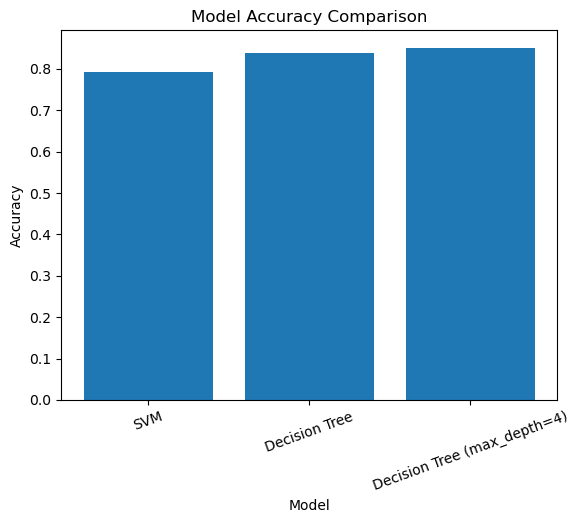

In [91]:
plt.bar(final_results["Model"], final_results["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

In [92]:
print("Conclusion:")
print("Both SVM and Decision Tree were applied to the Pima Indians Diabetes dataset.")
print("SVM was trained using normalized features because SVM is sensitive to feature scale.")
print("Decision Tree was trained using the original features because scaling is not required.")
print("The performance of both models was compared using accuracy, precision, recall, and F1-score.")
print("A deep Decision Tree can overfit the training data.")
print("Limiting the tree depth can reduce overfitting and improve generalization.")

Conclusion:
Both SVM and Decision Tree were applied to the Pima Indians Diabetes dataset.
SVM was trained using normalized features because SVM is sensitive to feature scale.
Decision Tree was trained using the original features because scaling is not required.
The performance of both models was compared using accuracy, precision, recall, and F1-score.
A deep Decision Tree can overfit the training data.
Limiting the tree depth can reduce overfitting and improve generalization.
